In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    benchmark_data = json.load(f)

print(f"Loaded {len(benchmark_data)} configurations")
print(f"Configurations: {[config['config_name'] for config in benchmark_data]}")


Loaded 7 configurations
Configurations: ['spacy', 'ai4privacy', 'edsnlp', 'spacy+ai4privacy', 'spacy+edsnlp', 'ai4privacy+edsnlp', 'all']


In [3]:
def prepare_data_for_plotting(benchmark_data, metric_type='entity_aware'):
    """
    Prepare data for plotting grouped bar charts.
    
    Returns:
        df: DataFrame with columns: entity_type, config_name, precision, recall, f1
    """
    rows = []
    for config in benchmark_data:
        config_name = config['config_name']
        metrics = config[metric_type]
        for metric in metrics:
            rows.append({
                'entity_type': metric['entity_type'],
                'config_name': config_name,
                'precision': metric['precision'],
                'recall': metric['recall'],
                'f1': metric['f1']
            })
    return pd.DataFrame(rows)

# Prepare data for both entity_aware and entity_unaware
df_aware = prepare_data_for_plotting(benchmark_data, 'entity_aware')
df_unaware = prepare_data_for_plotting(benchmark_data, 'entity_unaware')

print("Entity-aware data shape:", df_aware.shape)
print("Entity-unaware data shape:", df_unaware.shape)
print("\nEntity types:", sorted(df_aware['entity_type'].unique()))


Entity-aware data shape: (118, 5)
Entity-unaware data shape: (118, 5)

Entity types: ['AGE', 'CREDIT_CARD', 'DATE_TIME', 'DRIVERLICENSENUM', 'EMAIL_ADDRESS', 'GENDER', 'IBAN_CODE', 'IDCARDNUM', 'ID_CARD', 'IP_ADDRESS', 'LOCATION', 'ORGANIZATION', 'PASSPORTNUM', 'PERSON', 'PHONE_NUMBER', 'TAXNUM', 'URL', 'US_SSN']


In [4]:
entities_to_plot = ['AGE', 'CREDIT_CARD', 'DATE_TIME', 'DRIVERLICENSENUM', 'EMAIL_ADDRESS', 'GENDER', 'IDCARDNUM', 'LOCATION', 'PASSPORTNUM', 'PERSON', 'PHONE_NUMBER', 'TAXNUM']

def plot_metrics(df, title_prefix, figsize=(18, 6)):
    """
    Create 3 bar plots side by side for precision, recall, and F1.
    """
    # Get unique entity types and config names
    entity_types = entities_to_plot
    config_names = ["spacy", "ai4privacy", "edsnlp", "spacy+ai4privacy", "spacy+edsnlp", "ai4privacy+edsnlp", "all"]
    
    # Set up the figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(title_prefix, fontsize=16, fontweight='bold')
    
    metrics = ['precision', 'recall', 'f1']
    metric_labels = ['Precision', 'Recall', 'F1 Score']
    
    # Set up colors for each config
    colors = plt.cm.Set1(np.linspace(0, 1, len(config_names)))
    color_map = {config: colors[i] for i, config in enumerate(config_names)}
    
    # Width of bars
    x = np.arange(len(entity_types))
    width = 0.8 / len(config_names)
    
    for ax_idx, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[ax_idx]
        
        # Plot bars for each config
        for i, config_name in enumerate(config_names):
            values = []
            for entity_type in entity_types:
                value = df[(df['entity_type'] == entity_type) & 
                          (df['config_name'] == config_name)][metric].values
                values.append(value[0] if len(value) > 0 else 0)
            
            offset = (i - len(config_names) / 2 + 0.5) * width
            ax.bar(x + offset, values, width, label=config_name, 
                  color=color_map[config_name], alpha=0.8)
        
        ax.set_xlabel('Entity Type', fontsize=10)
        ax.set_ylabel(metric_label, fontsize=10)
        ax.set_title(metric_label, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(entity_types, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(fontsize=8, loc='upper left')
    
    plt.tight_layout()
    return fig


## Entity aware benchmark

- We compute entity aware metrics for each entity type `E`:
    - TP if detected class and ground truth are both `E`
    - FN ground truth is `E` and detected is different
    - FP detected is `E` and ground truth is different

Reminder:
$$
Precision = TP/(TP + FP)
$$
$$
Recall = TP/(TP + FN)
$$
$$
F1=2*(Precision*Recall)/(Precision + Recall)
$$

In our case for privacy masking, we will be mainly optimizing recall.

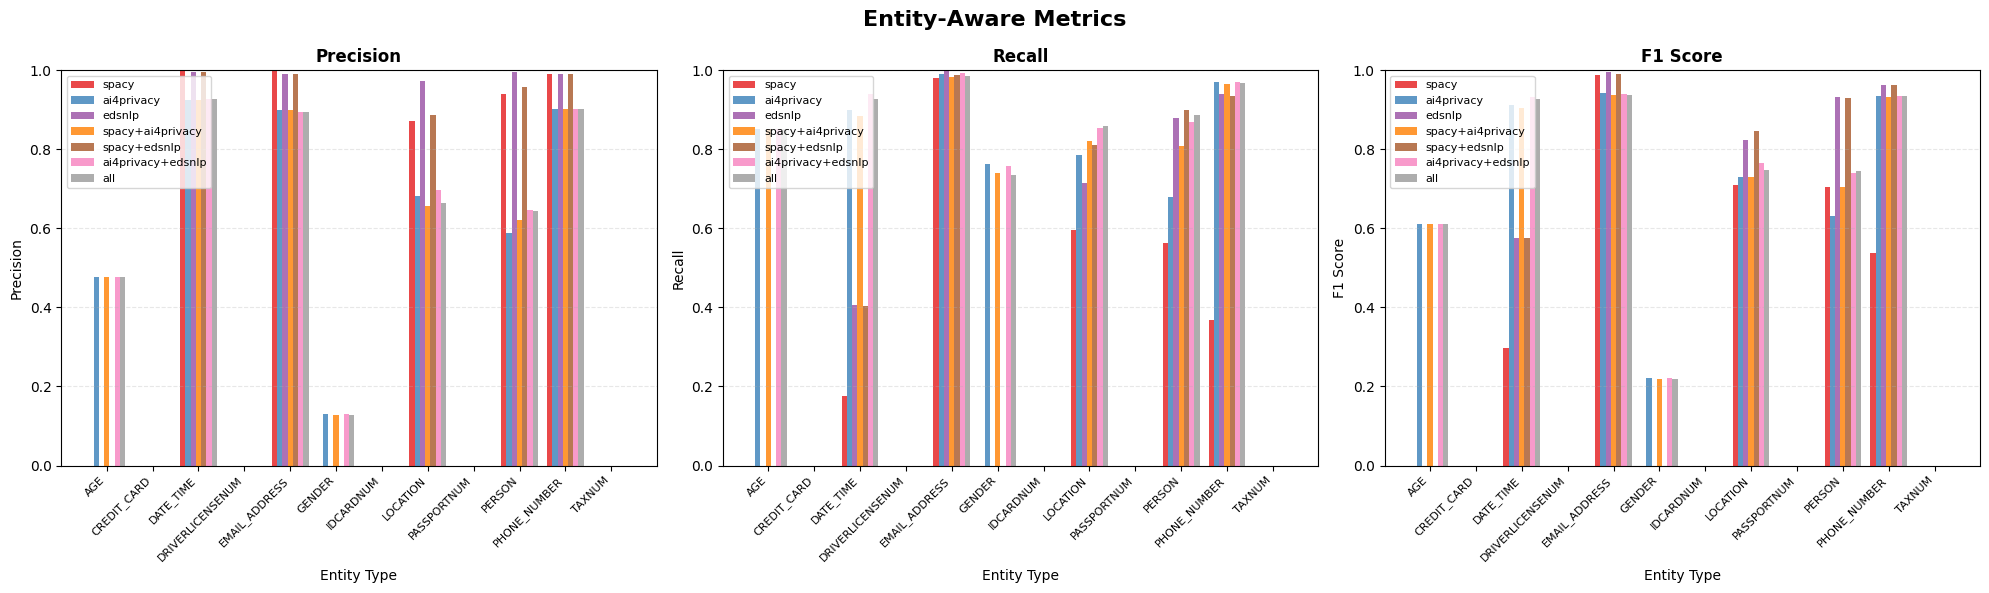

In [5]:
# Plot entity-aware metrics
fig1 = plot_metrics(df_aware, 'Entity-Aware Metrics', figsize=(20, 6))
plt.show()

## Entity un-aware benchmark

- We compute entity aware metrics for each entity type `E`:
    - TP if ground truth is `E` and detected class is any of the detection class (not `O`)
    - FN ground truth is `E` and no detection
    - FP detected is `E` and ground truth is `O`

Basically we acounted for the fact that the model can recognize a PERSON as a LOCATION for instance, and in these metrics it is assumed as ok.

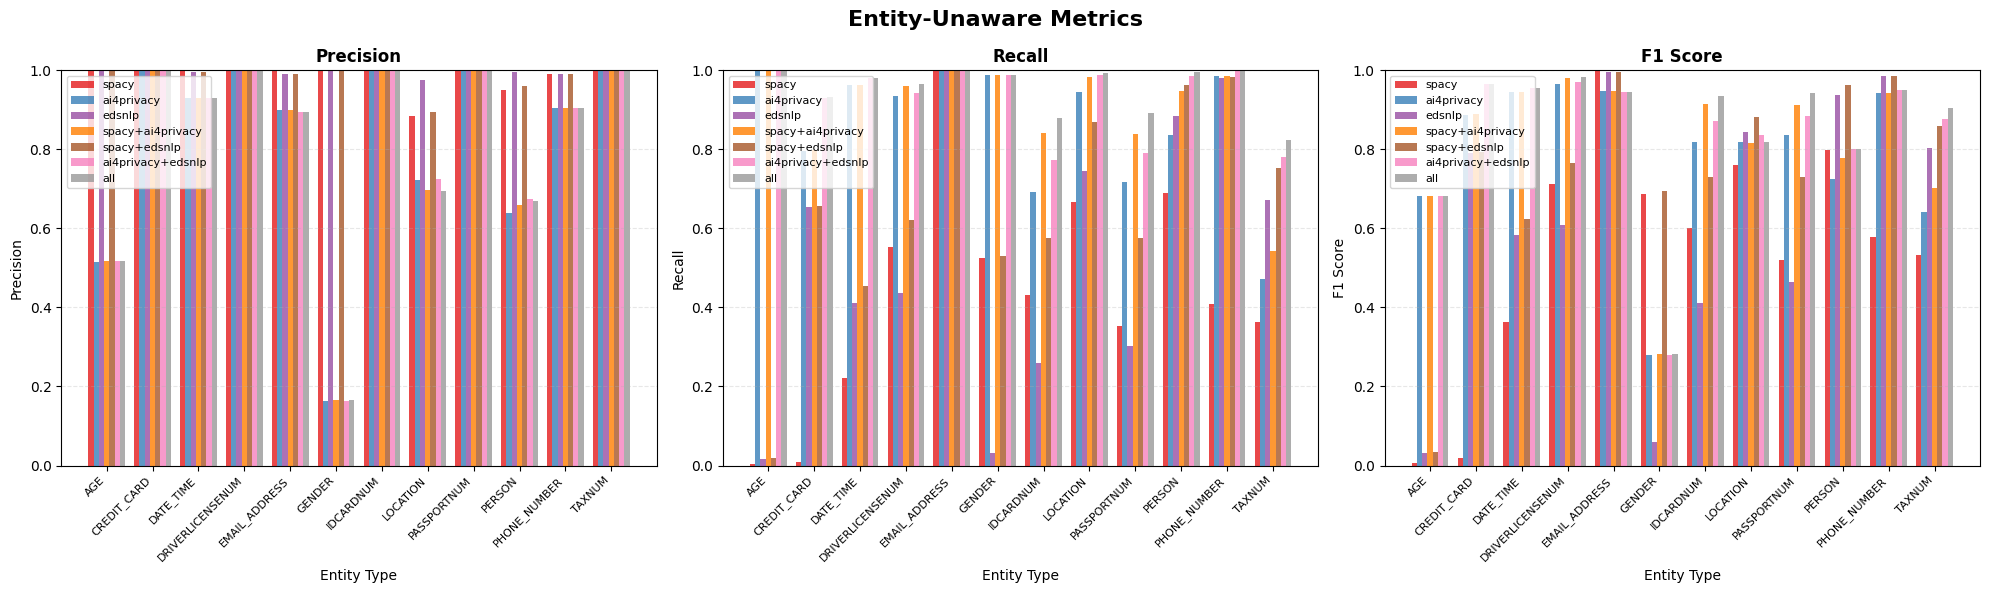

In [6]:
# Plot entity-unaware metrics
fig2 = plot_metrics(df_unaware, 'Entity-Unaware Metrics', figsize=(20, 6))
plt.show()


In [7]:
def compute_and_plot_confusion_matrix(csv_path, config_name, max_labels=None):
    """Load word-level CSV and compute confusion matrix."""
    print(f"\n{'='*60}")
    print(f"Computing confusion matrix for: {config_name}")
    print(f"{'='*60}")
    
    # Load the CSV
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} word-level rows")
    
    # Get all unique labels
    all_labels = sorted(set(df['gt_label'].unique()) | set(df['det_label'].unique()))
    
    # Limit to most common labels if requested
    if max_labels:
        # Count label frequencies
        gt_counts = df['gt_label'].value_counts()
        det_counts = df['det_label'].value_counts()
        combined_counts = (gt_counts + det_counts).sort_values(ascending=False)
        top_labels = combined_counts.head(max_labels).index.tolist()
        # Always include 'O' if present
        if 'O' in all_labels and 'O' not in top_labels:
            top_labels.append('O')
        all_labels = sorted([l for l in all_labels if l in top_labels])
        print(f"Using top {len(all_labels)} labels (including 'O' if present)")
    
    # Filter dataframe to only include selected labels
    df_filtered = df[df['gt_label'].isin(all_labels) & df['det_label'].isin(all_labels)]
    
    # Compute confusion matrix
    cm = confusion_matrix(
        df_filtered['gt_label'],
        df_filtered['det_label'],
        labels=all_labels
    )
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Normalize confusion matrix to percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # Handle division by zero
    
    # Plot confusion matrix
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=all_labels,
        yticklabels=all_labels,
        ax=ax,
        cbar_kws={'label': 'Normalized Frequency'}
    )
    
    ax.set_xlabel('Predicted Label (det_label)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label (gt_label)', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix - {config_name}\n(Normalized by True Label)', 
                 fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(
        df_filtered['gt_label'],
        df_filtered['det_label'],
        labels=all_labels,
        zero_division=0
    ))
    
    # Print some statistics
    print(f"\nTotal words: {len(df_filtered)}")
    print(f"Correct predictions: {(df_filtered['gt_label'] == df_filtered['det_label']).sum()}")
    print(f"Accuracy: {(df_filtered['gt_label'] == df_filtered['det_label']).mean():.4f}")
    
    return cm, all_labels

# Configuration: limit to top N labels for readability (set to None for all labels)
MAX_LABELS = 15  # Adjust this number as needed



Computing confusion matrix for: spacy
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


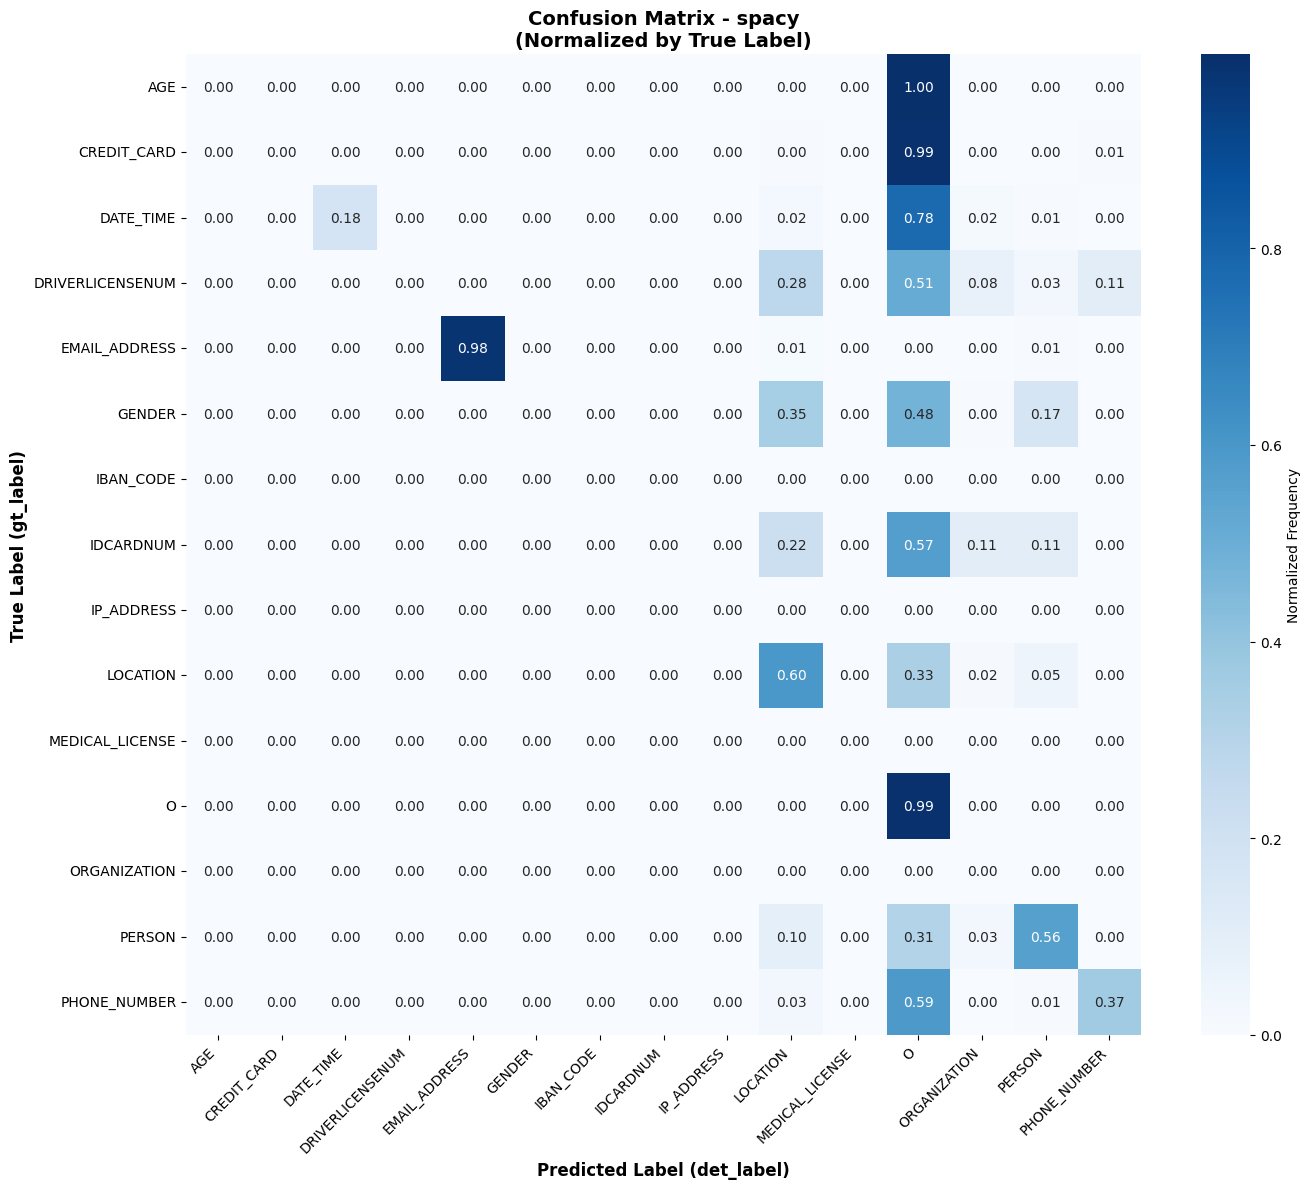


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.00      0.00      0.00      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       1.00      0.18      0.30     23338
DRIVERLICENSENUM       0.00      0.00      0.00      1709
   EMAIL_ADDRESS       1.00      0.98      0.99     14326
          GENDER       0.00      0.00      0.00      1017
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1697
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.58      0.60      0.59     16193
 MEDICAL_LICENSE       0.00      0.00      0.00         0
               O       0.90      0.99      0.95    467670
    ORGANIZATION       0.00      0.00      0.00         0
          PERSON       0.87      0.56      0.68     33683
    PHONE_NUMBER       0.96      0.37      0.53     20554

        accuracy                           0.8

In [8]:
# Confusion matrix for spacy
cm_spacy, labels_spacy = compute_and_plot_confusion_matrix(
    'spacy_detections_word_level.csv',
    'spacy',
    max_labels=MAX_LABELS
)



Computing confusion matrix for: ai4privacy
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


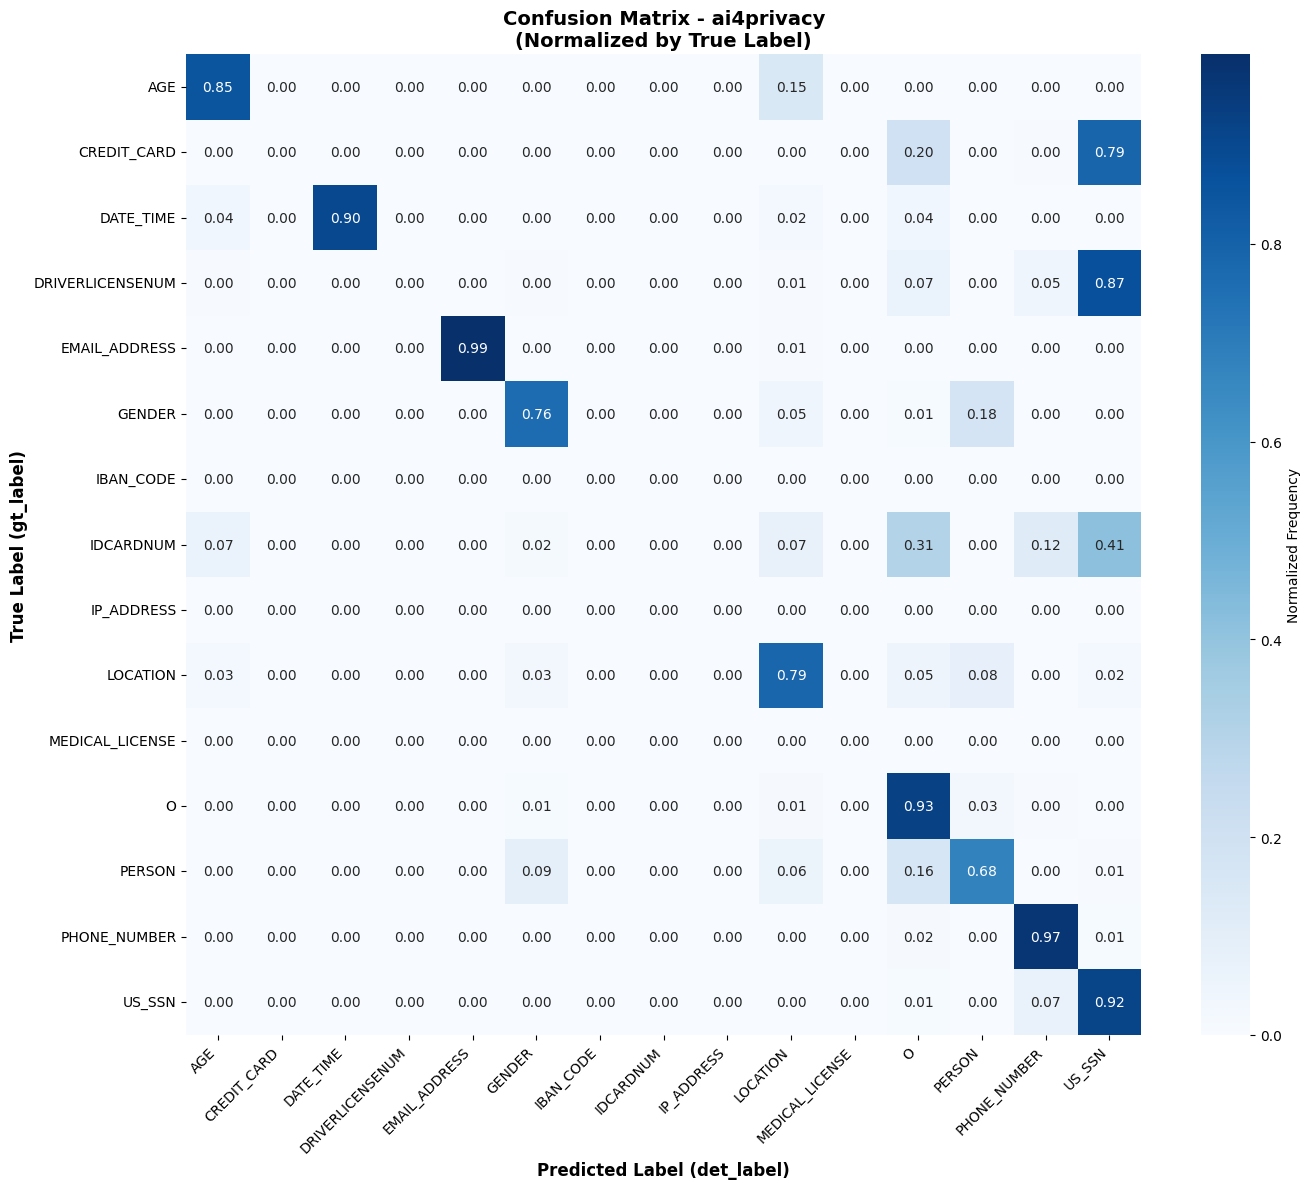


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.28      0.85      0.42      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       0.92      0.90      0.91     23338
DRIVERLICENSENUM       0.00      0.00      0.00      1901
   EMAIL_ADDRESS       0.89      0.99      0.94     14334
          GENDER       0.08      0.76      0.15      1017
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1698
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.59      0.79      0.67     16193
 MEDICAL_LICENSE       0.00      0.00      0.00         0
               O       0.98      0.93      0.95    467695
          PERSON       0.57      0.68      0.62     33682
    PHONE_NUMBER       0.88      0.97      0.92     20554
          US_SSN       0.30      0.92      0.45      2267

        accuracy                           0.9

In [9]:
# Confusion matrix for ai4privacy
cm_ai4privacy, labels_ai4privacy = compute_and_plot_confusion_matrix(
    'ai4privacy_detections_word_level.csv',
    'ai4privacy',
    max_labels=MAX_LABELS
)



Computing confusion matrix for: edsnlp
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


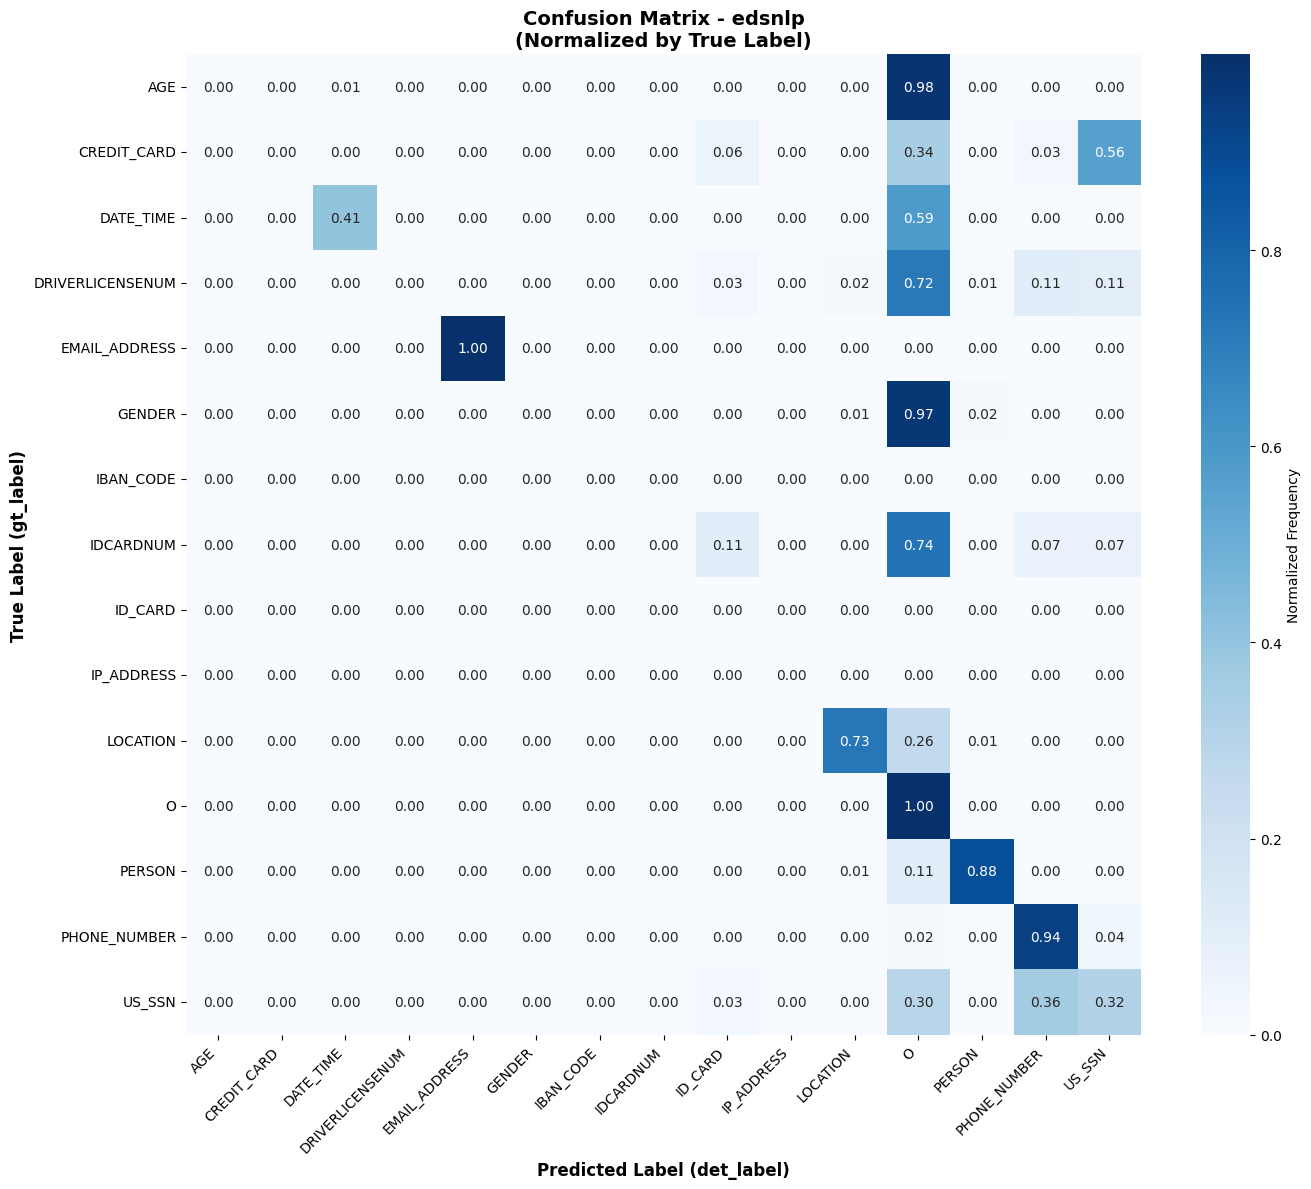


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.00      0.00      0.00      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       0.99      0.41      0.58     23338
DRIVERLICENSENUM       0.00      0.00      0.00      1521
   EMAIL_ADDRESS       0.99      1.00      0.99     14334
          GENDER       0.00      0.00      0.00      1017
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1697
         ID_CARD       0.00      0.00      0.00         0
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.95      0.73      0.82     15930
               O       0.94      1.00      0.97    467643
          PERSON       0.99      0.88      0.93     33660
    PHONE_NUMBER       0.93      0.94      0.94     20554
          US_SSN       0.33      0.32      0.32      2267

        accuracy                           0.9

In [10]:
# Confusion matrix for edsnlp
cm_edsnlp, labels_edsnlp = compute_and_plot_confusion_matrix(
    'edsnlp_detections_word_level.csv',
    'edsnlp',
    max_labels=MAX_LABELS
)



Computing confusion matrix for: spacy+ai4privacy
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


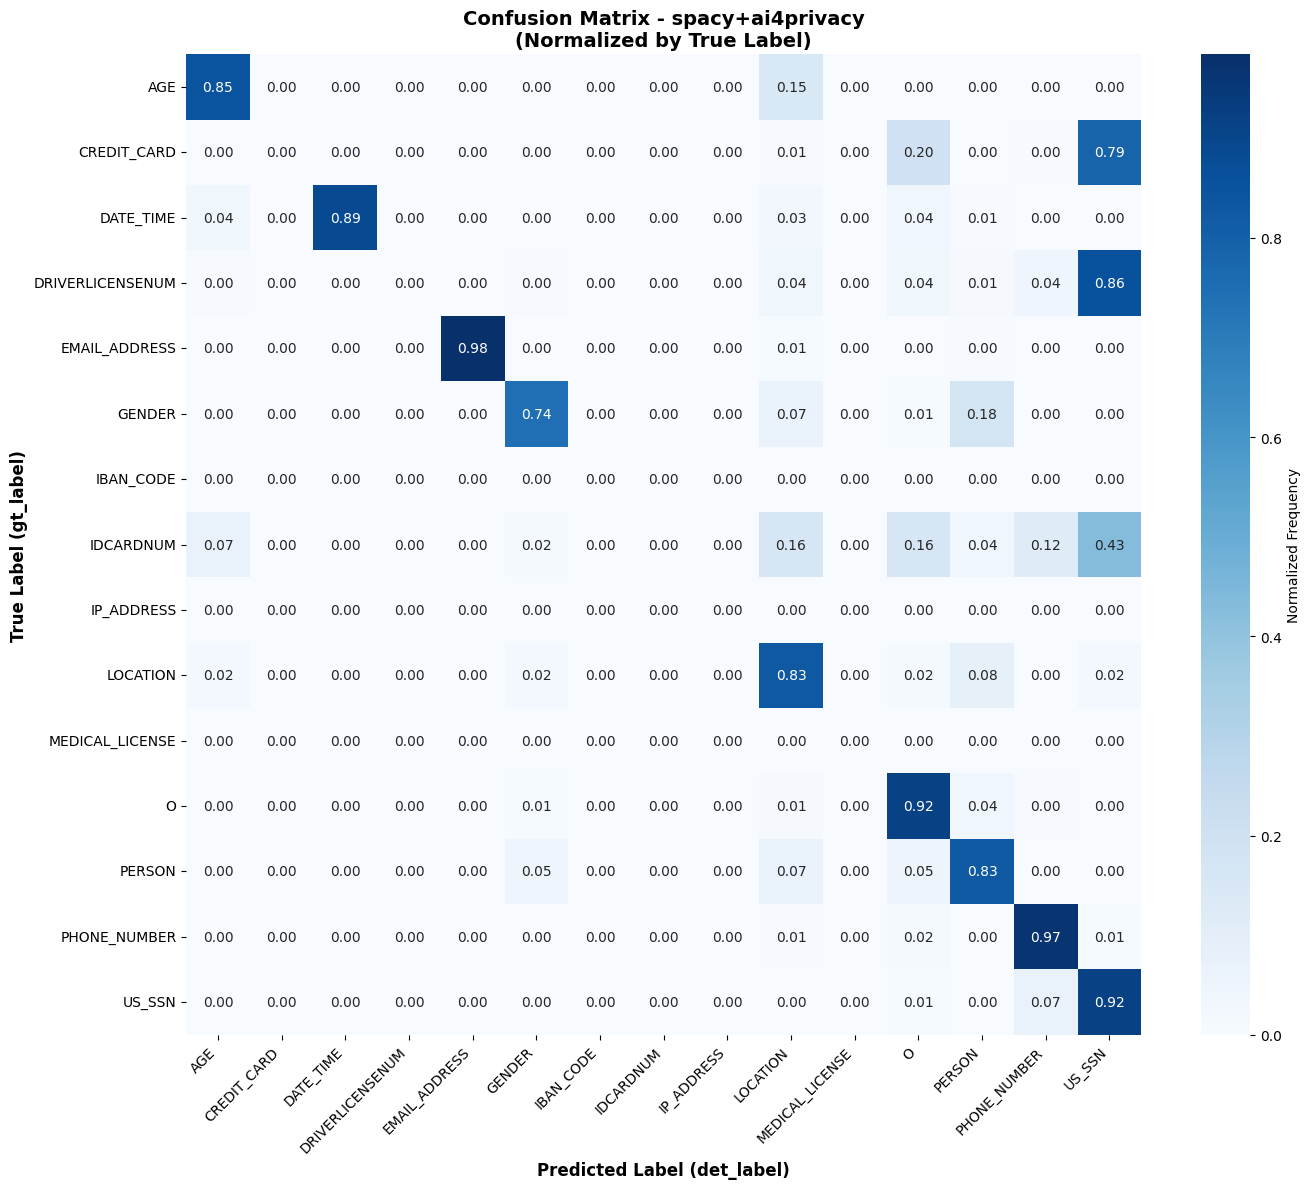


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.28      0.85      0.42      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       0.92      0.89      0.90     23279
DRIVERLICENSENUM       0.00      0.00      0.00      1898
   EMAIL_ADDRESS       0.90      0.98      0.94     14307
          GENDER       0.10      0.74      0.17      1014
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1632
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.55      0.83      0.66     16081
 MEDICAL_LICENSE       0.00      0.00      0.00         0
               O       0.99      0.92      0.96    467147
          PERSON       0.60      0.83      0.69     33005
    PHONE_NUMBER       0.88      0.97      0.92     20521
          US_SSN       0.31      0.92      0.46      2267

        accuracy                           0.9

In [11]:
# Confusion matrix for spacy+ai4privacy
cm_spacy_ai4privacy, labels_spacy_ai4privacy = compute_and_plot_confusion_matrix(
    'spacy+ai4privacy_detections_word_level.csv',
    'spacy+ai4privacy',
    max_labels=MAX_LABELS
)



Computing confusion matrix for: spacy+edsnlp
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


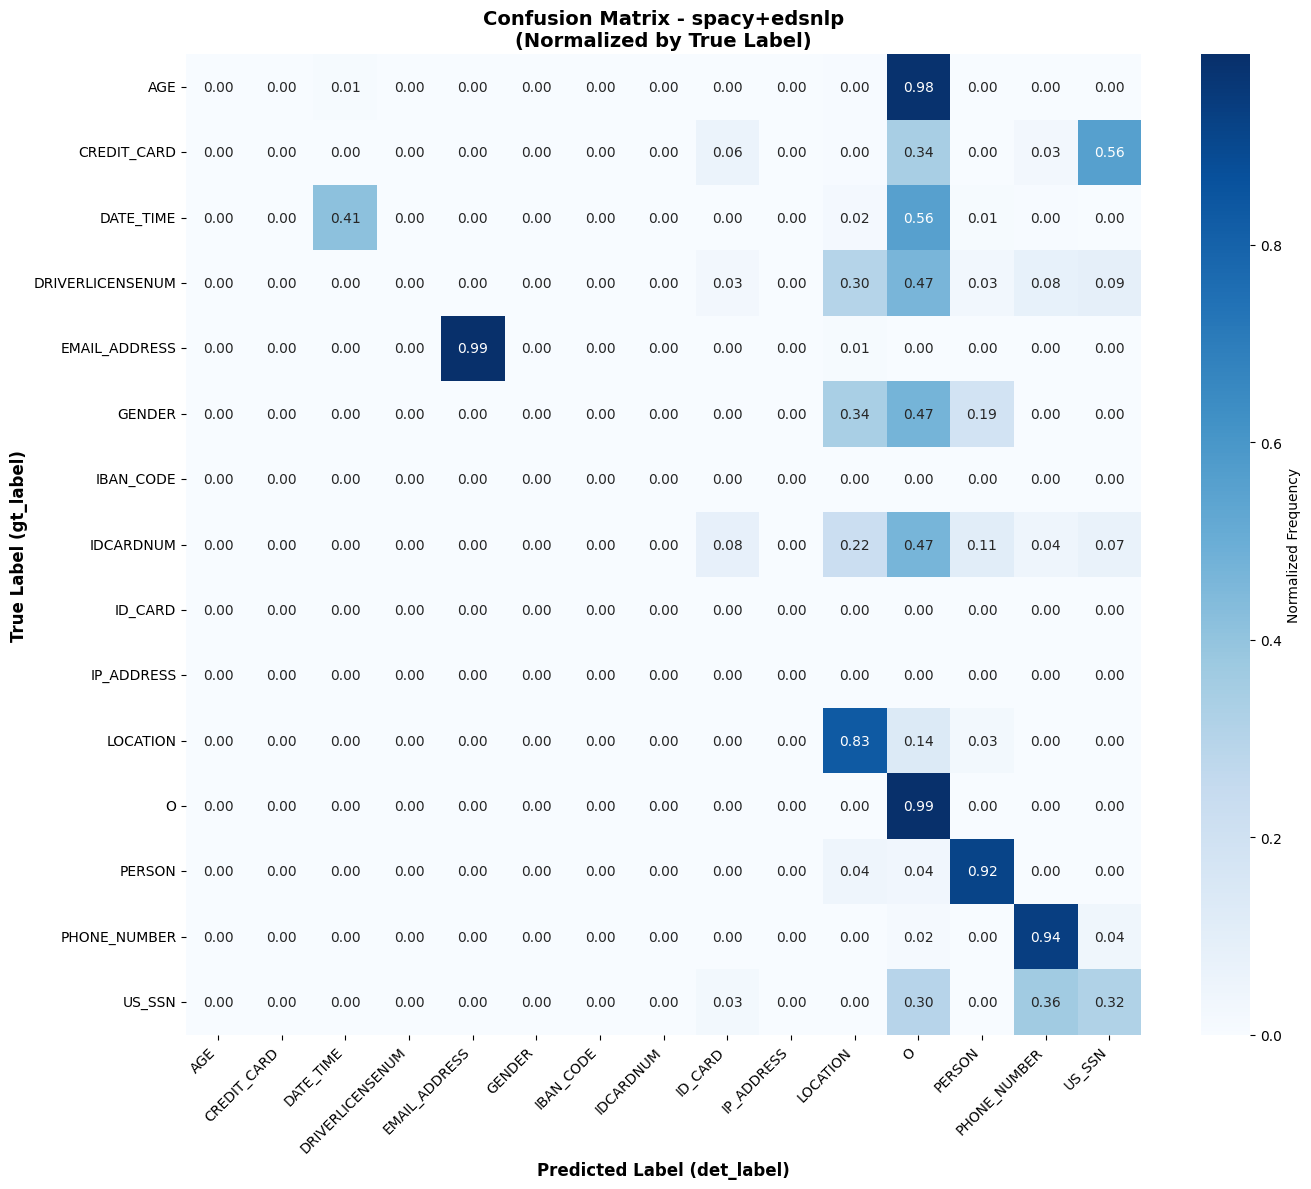


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.00      0.00      0.00      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       0.99      0.41      0.58     22945
DRIVERLICENSENUM       0.00      0.00      0.00      1587
   EMAIL_ADDRESS       0.99      0.99      0.99     14314
          GENDER       0.00      0.00      0.00      1012
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1542
         ID_CARD       0.00      0.00      0.00         0
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.73      0.83      0.78     15768
               O       0.96      0.99      0.98    467030
          PERSON       0.93      0.92      0.92     33037
    PHONE_NUMBER       0.94      0.94      0.94     20531
          US_SSN       0.34      0.32      0.33      2267

        accuracy                           0.9

In [12]:
# Confusion matrix for spacy+edsnlp
cm_spacy_edsnlp, labels_spacy_edsnlp = compute_and_plot_confusion_matrix(
    'spacy+edsnlp_detections_word_level.csv',
    'spacy+edsnlp',
    max_labels=MAX_LABELS
)



Computing confusion matrix for: ai4privacy+edsnlp
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


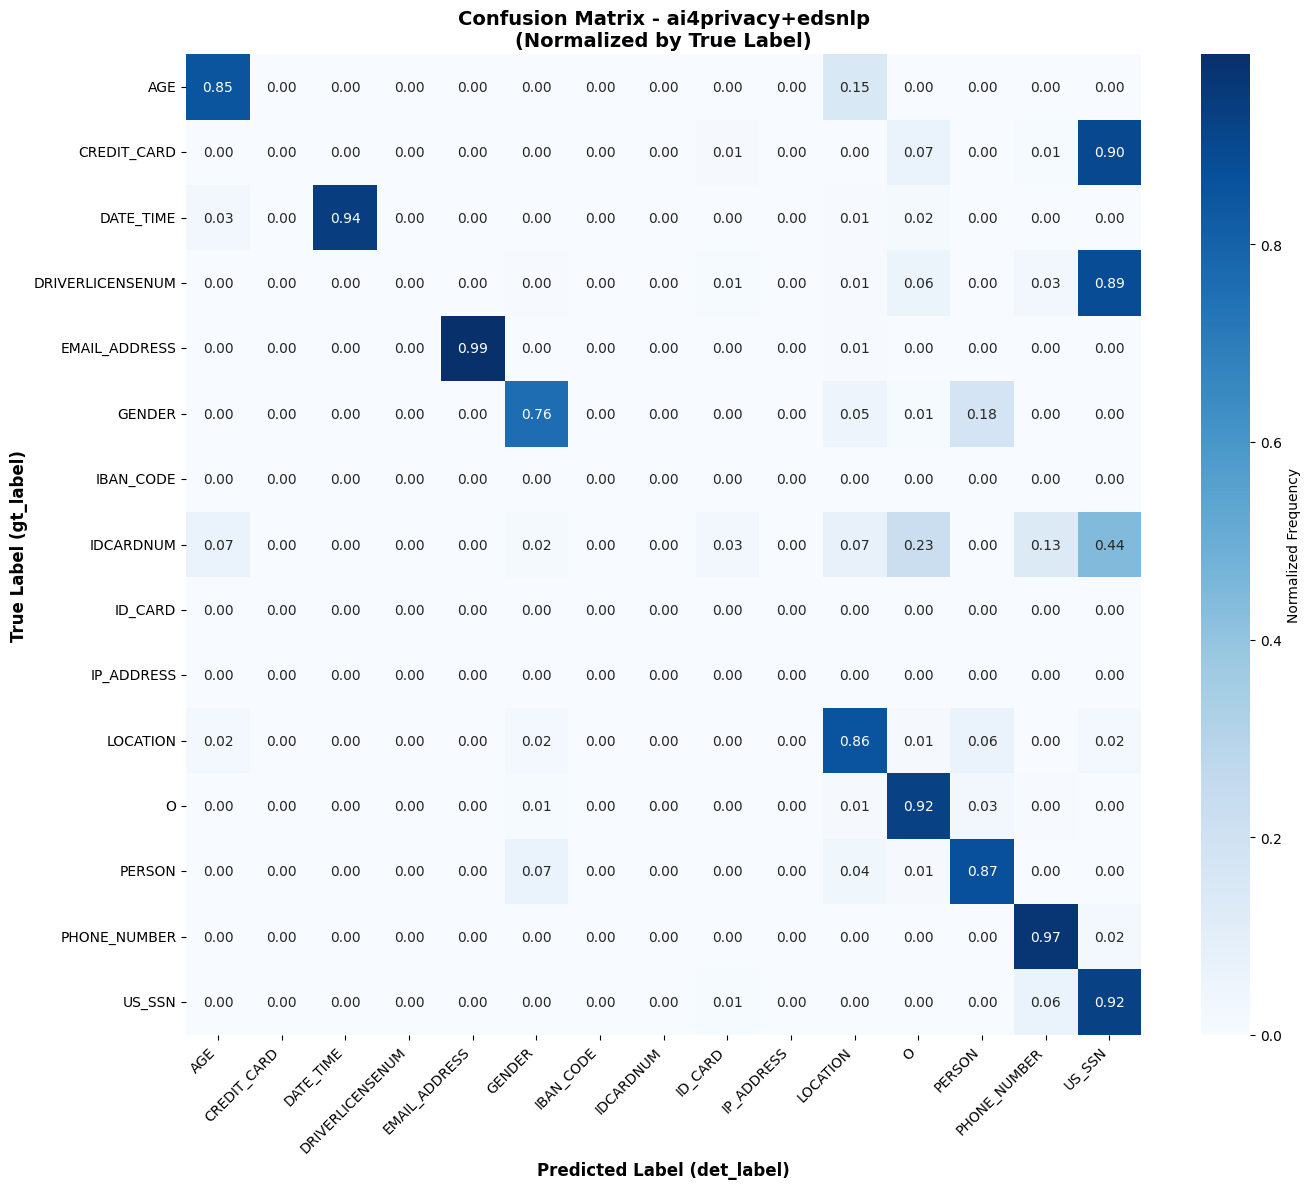


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.29      0.85      0.44      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       0.93      0.94      0.93     23338
DRIVERLICENSENUM       0.00      0.00      0.00      1903
   EMAIL_ADDRESS       0.89      0.99      0.94     14334
          GENDER       0.09      0.76      0.16      1017
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1698
         ID_CARD       0.00      0.00      0.00         0
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.63      0.86      0.73     16117
               O       1.00      0.92      0.96    467667
          PERSON       0.63      0.87      0.73     33669
    PHONE_NUMBER       0.88      0.97      0.93     20554
          US_SSN       0.29      0.92      0.44      2267

        accuracy                           0.9

In [13]:
# Confusion matrix for ai4privacy+edsnlp
cm_ai4privacy_edsnlp, labels_ai4privacy_edsnlp = compute_and_plot_confusion_matrix(
    'ai4privacy+edsnlp_detections_word_level.csv',
    'ai4privacy+edsnlp',
    max_labels=MAX_LABELS
)



Computing confusion matrix for: all (spacy+ai4privacy+edsnlp)
Loaded 587733 word-level rows
Using top 15 labels (including 'O' if present)


/tmp/ipykernel_36196/1820899699.py:41: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


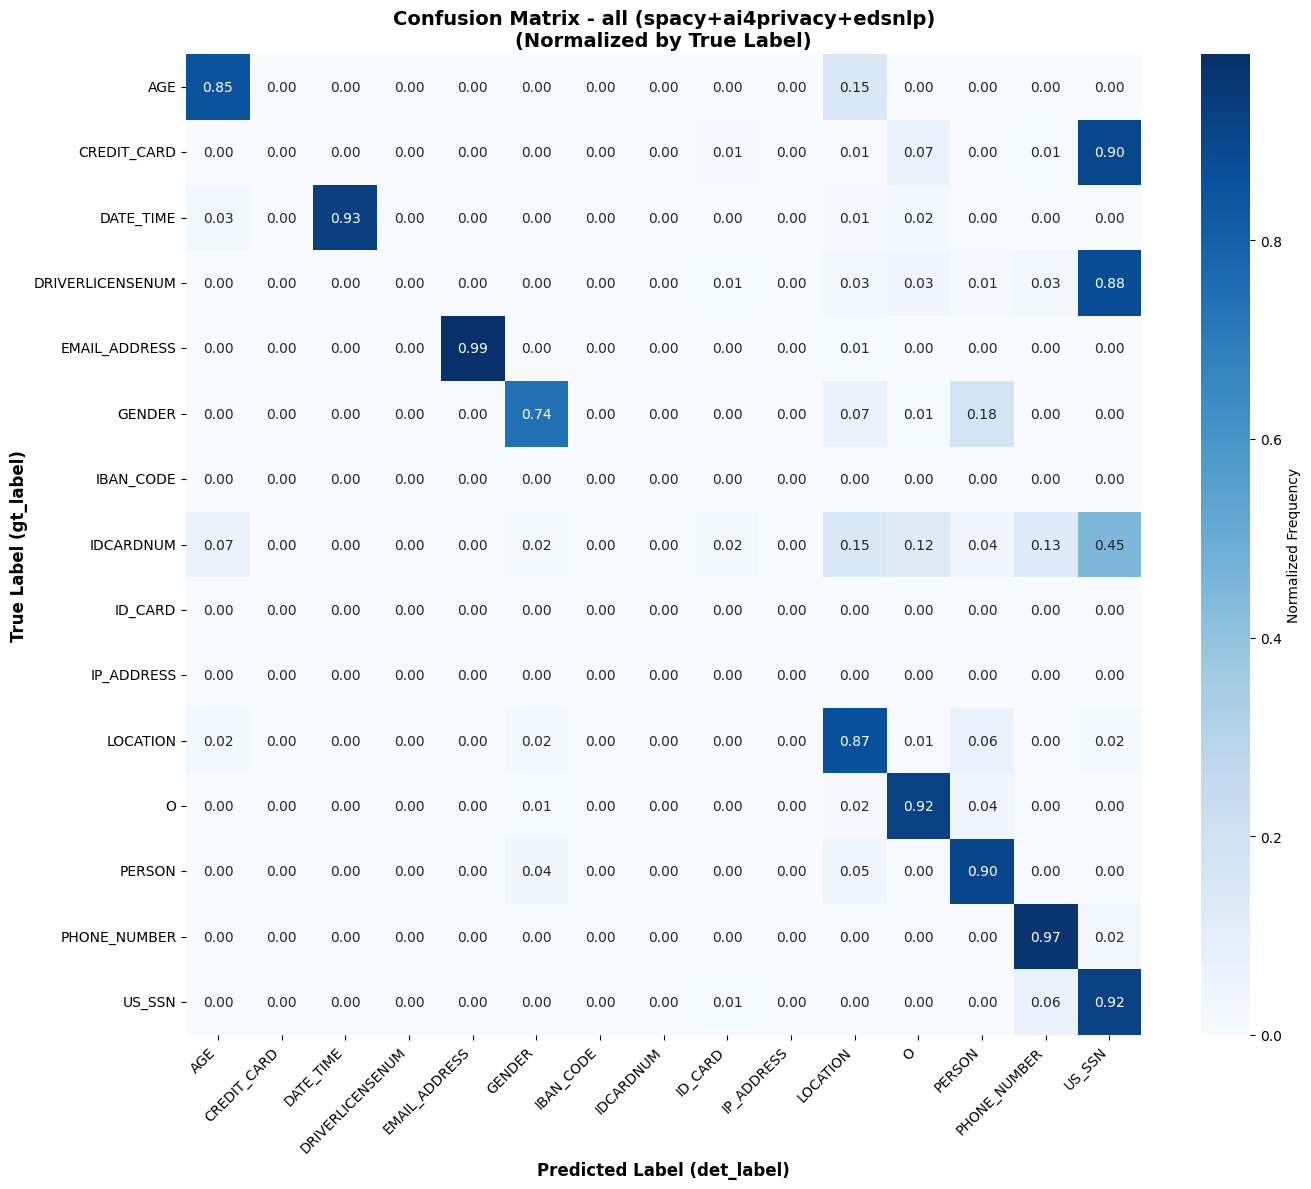


Classification Report:
                  precision    recall  f1-score   support

             AGE       0.30      0.85      0.44      1126
     CREDIT_CARD       0.00      0.00      0.00       493
       DATE_TIME       0.93      0.93      0.93     23280
DRIVERLICENSENUM       0.00      0.00      0.00      1899
   EMAIL_ADDRESS       0.89      0.99      0.94     14319
          GENDER       0.10      0.74      0.17      1014
       IBAN_CODE       0.00      0.00      0.00         0
       IDCARDNUM       0.00      0.00      0.00      1643
         ID_CARD       0.00      0.00      0.00         0
      IP_ADDRESS       0.00      0.00      0.00         0
        LOCATION       0.59      0.87      0.70     16041
               O       1.00      0.92      0.96    467127
          PERSON       0.62      0.90      0.74     33131
    PHONE_NUMBER       0.88      0.97      0.93     20535
          US_SSN       0.30      0.92      0.45      2267

        accuracy                           0.9

In [14]:
# Confusion matrix for all (spacy+ai4privacy+edsnlp)
cm_all, labels_all = compute_and_plot_confusion_matrix(
    'all_detections_word_level.csv',
    'all (spacy+ai4privacy+edsnlp)',
    max_labels=MAX_LABELS
)


## Entity-arbitrary metrics

Given a list of entity types to consider as "sensitive", we collapse all of them into a single `PRIVATE` class and everything else (including `O`) into `OTHER`. We then compute TP, FP, FN and derive precision, recall and F1 on this binary classification, one config at a time.

In [15]:
def compute_entity_arbitrary_metrics(df: pd.DataFrame, target_entities: list[str]) -> dict:
    """
    Compute binary PRIVATE vs OTHER metrics from a word-level dataframe.

    Any token whose gt_label / det_label is in `target_entities` is mapped to
    'PRIVATE'; everything else (including 'O') is mapped to 'OTHER'.

    Returns a dict with keys: tp, fp, fn, precision, recall, f1
    and a breakdown per original entity type.
    """
    target_set = set(target_entities)

    def collapse(label: str) -> str:
        return "PRIVATE" if label in target_set else "OTHER"

    gt_bin  = df["gt_label"].map(collapse)
    det_bin = df["det_label"].map(collapse)

    tp = ((gt_bin == "PRIVATE") & (det_bin == "PRIVATE")).sum()
    fp = ((gt_bin == "OTHER")   & (det_bin == "PRIVATE")).sum()
    fn = ((gt_bin == "PRIVATE") & (det_bin == "OTHER")).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # Per original entity breakdown (only for tokens whose GT is in target_entities)
    breakdown_rows = []
    for entity in sorted(target_set):
        e_tp = ((df["gt_label"] == entity) & (det_bin == "PRIVATE")).sum()
        e_fn = ((df["gt_label"] == entity) & (det_bin == "OTHER")).sum()
        e_fp = ((df["det_label"] == entity) & (gt_bin == "OTHER")).sum()
        e_prec = e_tp / (e_tp + e_fp) if (e_tp + e_fp) > 0 else 0.0
        e_rec  = e_tp / (e_tp + e_fn) if (e_tp + e_fn) > 0 else 0.0
        e_f1   = 2 * e_prec * e_rec / (e_prec + e_rec) if (e_prec + e_rec) > 0 else 0.0
        breakdown_rows.append({
            "entity": entity, "tp": e_tp, "fp": e_fp, "fn": e_fn,
            "precision": e_prec, "recall": e_rec, "f1": e_f1,
        })

    return {
        "tp": tp, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall, "f1": f1,
        "breakdown": pd.DataFrame(breakdown_rows),
    }


def plot_arbitrary_metrics(results: dict[str, dict], target_entities: list[str]):
    """
    Display a bar chart with precision / recall / F1 for each config,
    plus a per-entity breakdown table.
    """
    configs = list(results.keys())
    metrics = ["precision", "recall", "f1"]
    colors  = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    x     = np.arange(len(configs))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(configs) * 1.5), 5))
    for i, (metric, color) in enumerate(zip(metrics, colors)):
        values = [results[c][metric] for c in configs]
        ax.bar(x + (i - 1) * width, values, width,
               label=metric.capitalize(), color=color, alpha=0.85,
               edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=20, ha="right", fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(
        f"Binary PRIVATE vs OTHER — target entities: {', '.join(sorted(target_entities))}",
        fontsize=12, fontweight="bold"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

    # Print per-entity breakdown for each config
    for config, res in results.items():
        print(f"\n--- {config} ---")
        print(f"  Global  → precision={res['precision']:.3f}  recall={res['recall']:.3f}  f1={res['f1']:.3f}  "
              f"(TP={res['tp']}, FP={res['fp']}, FN={res['fn']})")
        if not res["breakdown"].empty:
            print(res["breakdown"].to_string(index=False))

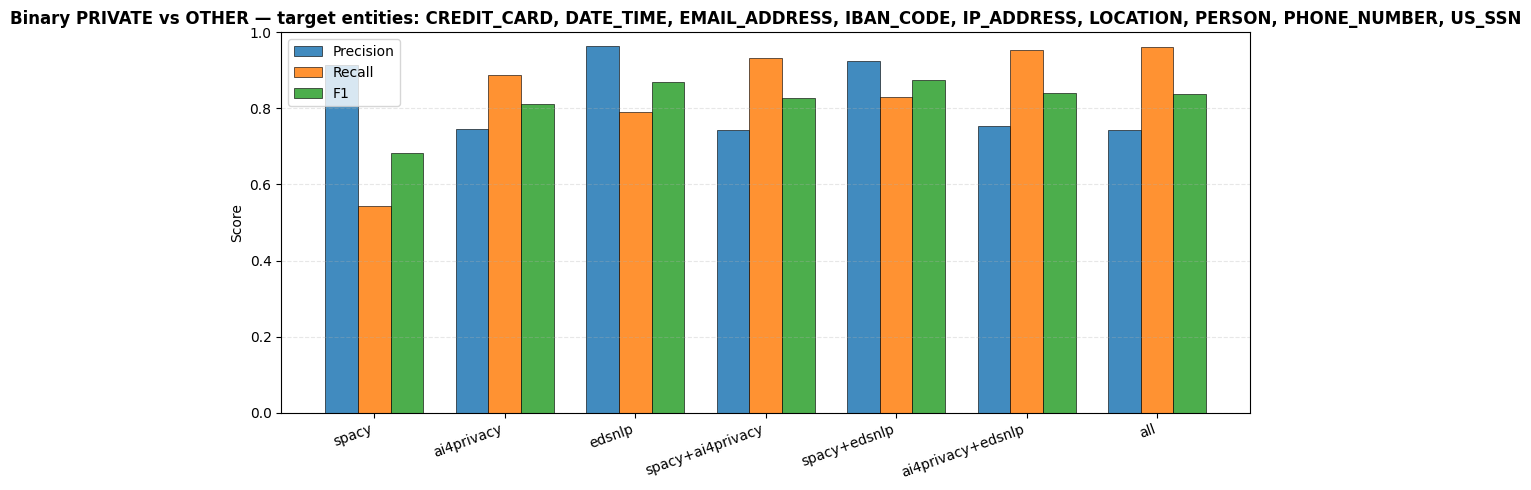


--- spacy ---
  Global  → precision=0.915  recall=0.543  f1=0.682  (TP=60247, FP=5623, FN=50615)
       entity    tp   fp    fn  precision   recall       f1
  CREDIT_CARD     5    0   488   1.000000 0.010142 0.020080
    DATE_TIME  4772    0 18566   1.000000 0.204473 0.339523
EMAIL_ADDRESS 14269    6    65   0.999580 0.995465 0.997518
    IBAN_CODE     0    5     0   0.000000 0.000000 0.000000
   IP_ADDRESS     0   16     0   0.000000 0.000000 0.000000
     LOCATION 10529 3088  5664   0.773225 0.650219 0.706407
       PERSON 22164 1709 11519   0.928413 0.658017 0.770172
 PHONE_NUMBER  8358  799 12196   0.912744 0.406636 0.562620
       US_SSN   150    0  2117   1.000000 0.066167 0.124121

--- ai4privacy ---
  Global  → precision=0.746  recall=0.887  f1=0.810  (TP=98328, FP=33506, FN=12534)
       entity    tp    fp   fn  precision   recall       f1
  CREDIT_CARD   391     0  102   1.000000 0.793103 0.884615
    DATE_TIME 21549  1694 1789   0.927118 0.923344 0.925227
EMAIL_ADDRESS 1430

In [17]:
# Edit this list to choose which entity types count as "PRIVATE"
TARGET_ENTITIES = [
    "PERSON",
    "EMAIL_ADDRESS",
    "PHONE_NUMBER",
    "LOCATION",
    "DATE_TIME",
    "IBAN_CODE",
    "IP_ADDRESS",
    "CREDIT_CARD",
    "US_SSN"
]

WORD_LEVEL_FILES = {
    "spacy":              "spacy_detections_word_level.csv",
    "ai4privacy":         "ai4privacy_detections_word_level.csv",
    "edsnlp":             "edsnlp_detections_word_level.csv",
    "spacy+ai4privacy":   "spacy+ai4privacy_detections_word_level.csv",
    "spacy+edsnlp":       "spacy+edsnlp_detections_word_level.csv",
    "ai4privacy+edsnlp":  "ai4privacy+edsnlp_detections_word_level.csv",
    "all":                "all_detections_word_level.csv",
}

arbitrary_results = {}
for config_name, csv_file in WORD_LEVEL_FILES.items():
    df_wl = pd.read_csv(csv_file)
    arbitrary_results[config_name] = compute_entity_arbitrary_metrics(df_wl, TARGET_ENTITIES)

plot_arbitrary_metrics(arbitrary_results, TARGET_ENTITIES)

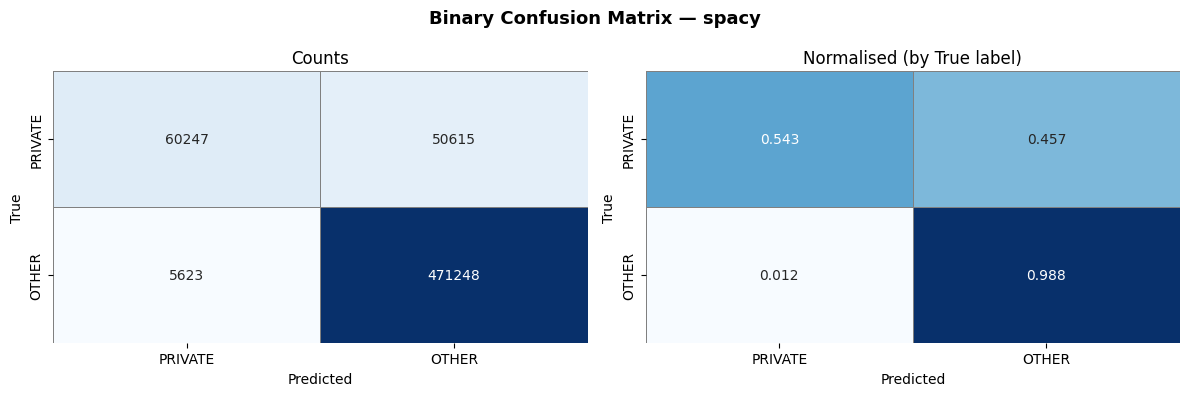

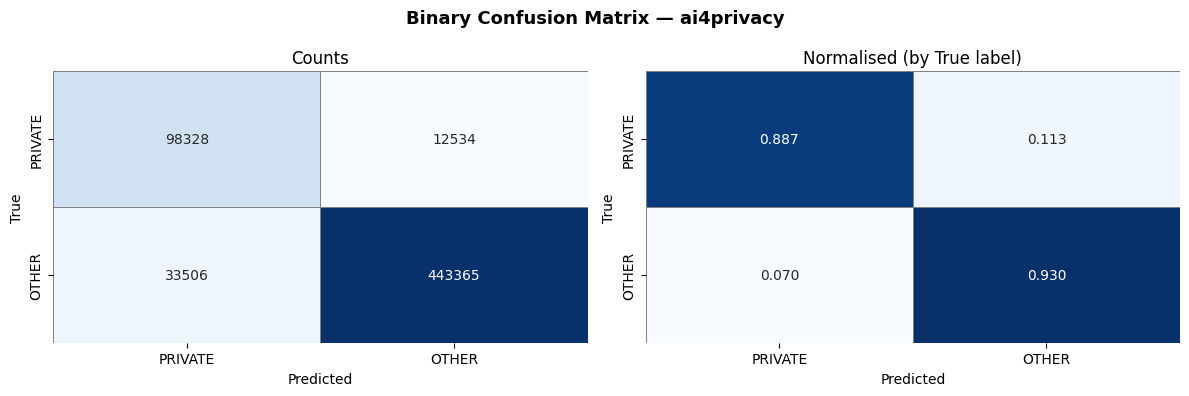

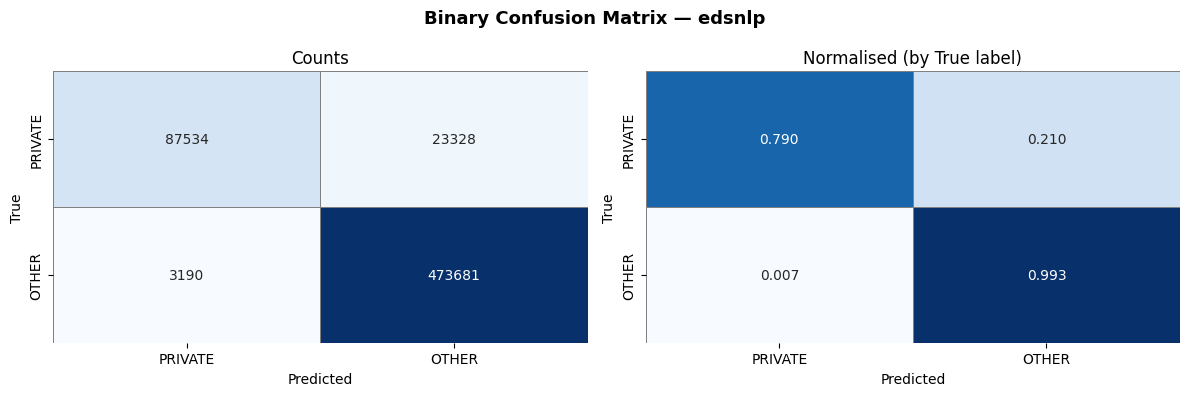

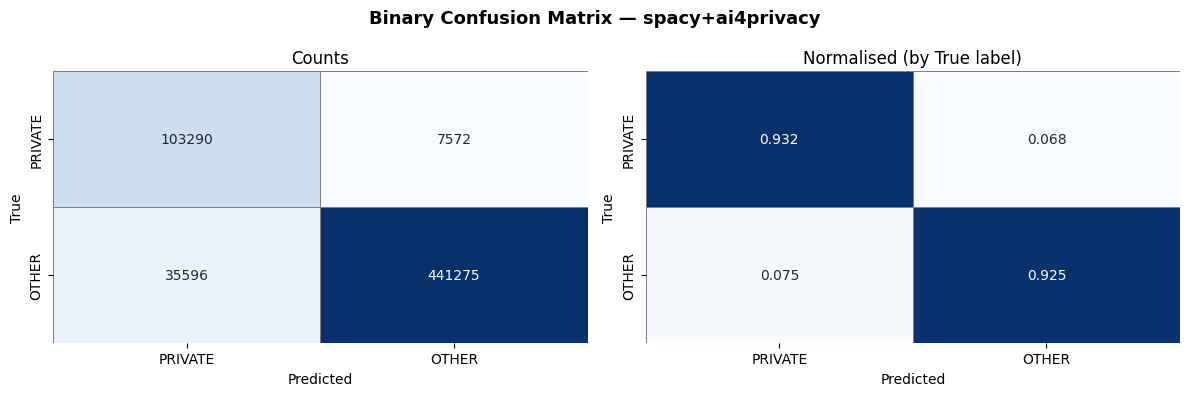

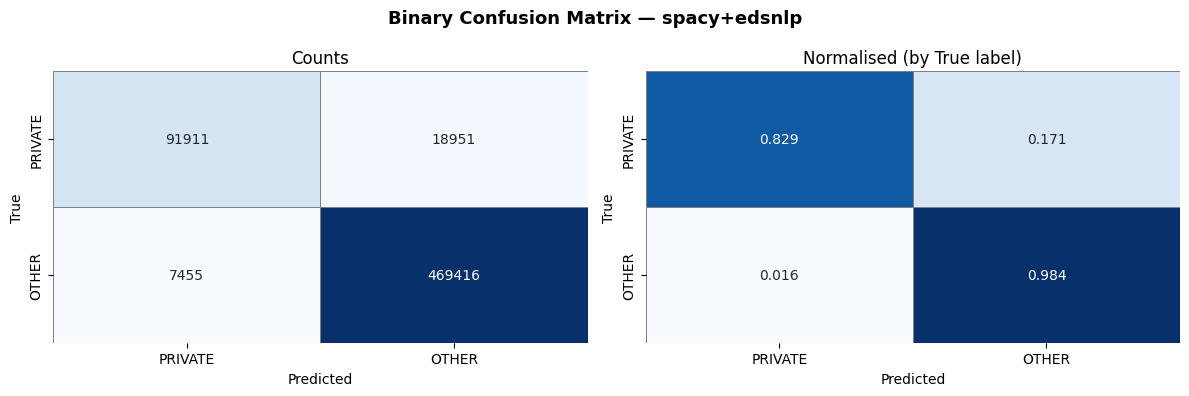

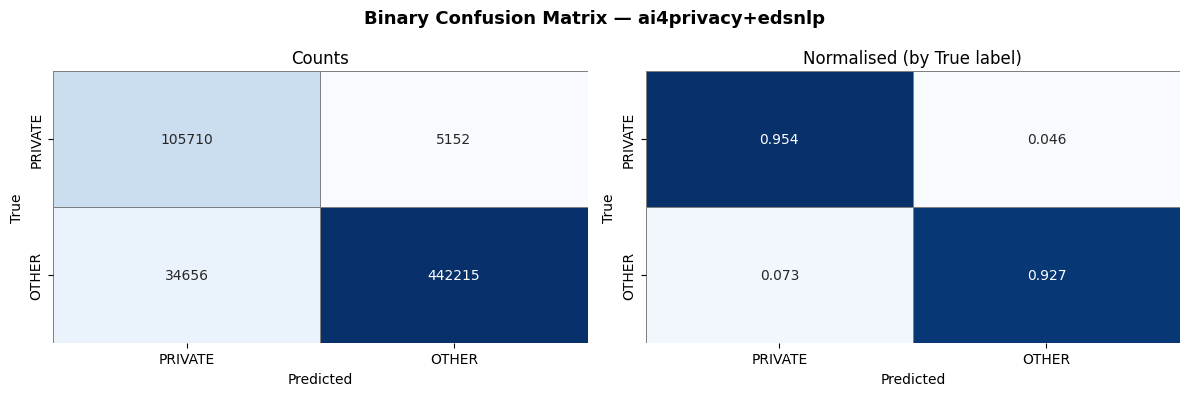

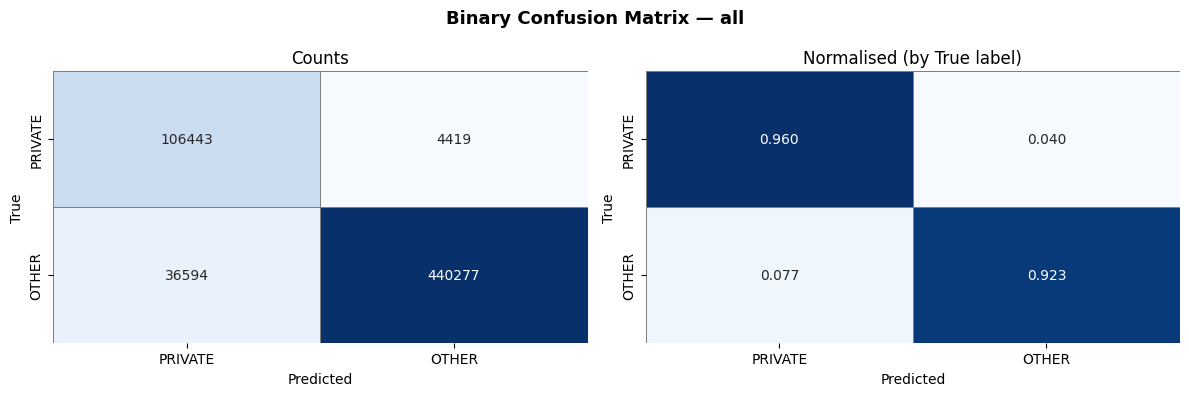

In [18]:
def plot_binary_confusion_matrix(csv_path, config_name, target_entities):
    """
    Load a word-level CSV and plot a 2x2 confusion matrix
    for the binary PRIVATE vs OTHER classification.
    """
    target_set = set(target_entities)

    df = pd.read_csv(csv_path)

    def collapse(label):
        return "PRIVATE" if label in target_set else "OTHER"

    gt_bin  = df["gt_label"].map(collapse)
    det_bin = df["det_label"].map(collapse)

    labels = ["PRIVATE", "OTHER"]
    cm = confusion_matrix(gt_bin, det_bin, labels=labels)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Binary Confusion Matrix — {config_name}", fontsize=13, fontweight="bold")

    # Raw counts
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        ax=axes[0], cbar=False,
        linewidths=0.5, linecolor="grey"
    )
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Counts")

    # Normalised
    sns.heatmap(
        cm_normalized, annot=True, fmt=".3f", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        ax=axes[1], cbar=False,
        linewidths=0.5, linecolor="grey"
    )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Normalised (by True label)")

    plt.tight_layout()
    plt.show()


for config_name, csv_file in WORD_LEVEL_FILES.items():
    plot_binary_confusion_matrix(csv_file, config_name, TARGET_ENTITIES)